<a href="https://colab.research.google.com/github/auliafakhirah/Linear-Regression---Fundamen-Sains-Data/blob/main/LOGISTIC_REGRESSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA ANGGOTA KELOMPOK:
1. Maulidya Iftitah (24523236)
2. Aulia Fakhirah Hendraini (24523020)

IMPORT

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [22]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


SPLIT DATA

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

MODEL

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

PREDIKSI

In [25]:
y_pred = model.predict(X_test)

CLASSIFICATION REPORT

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.89      0.93        47
           1       0.93      0.99      0.96        67

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



CONFUTION MATRIX

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[42,  5],
       [ 1, 66]])

VISUALISASI

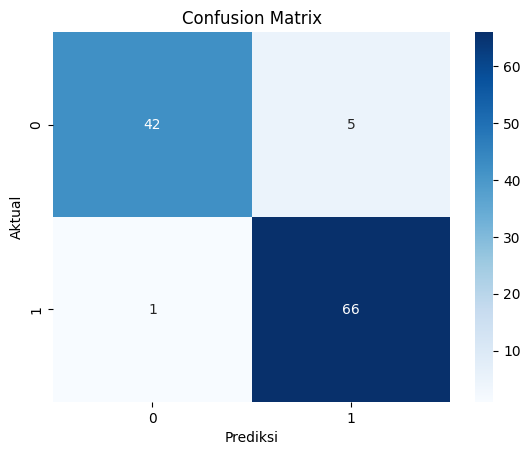

In [28]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()

HASIL PREDIKSI

In [29]:
hasil = pd.DataFrame({
    'Aktual': y_test.values,
    'Prediksi': y_pred
})

hasil.head(10)

,Aktual,Prediksi
0,0,0
1,1,1
2,0,0
3,0,0
4,0,0
5,1,1
6,1,1
7,0,0
8,0,1
9,1,1


ANALISIS LOGISTIC REGRESSION
1. Kinerja Model

Berdasarkan hasil classification report, model Logistic Regression menunjukkan performa yang sangat baik. Nilai precision, recall, dan f1-score pada masing-masing kelas mendekati 1, yang berarti model mampu melakukan klasifikasi dengan tingkat akurasi yang tinggi dan kesalahan yang rendah.

2. Makna TP, FP, TN, FN

Pada studi kasus klasifikasi (misalnya deteksi kanker):

True Positive (TP) → Model memprediksi positif (kanker), dan memang benar positif
False Positive (FP) → Model memprediksi positif, padahal sebenarnya negatif
True Negative (TN) → Model memprediksi negatif, dan memang benar negatif
False Negative (FN) → Model memprediksi negatif, padahal sebenarnya positif
3. Kesimpulan

Model Logistic Regression bekerja dengan sangat baik pada dataset yang digunakan. Hal ini ditunjukkan oleh nilai evaluasi yang tinggi serta jumlah kesalahan klasifikasi yang kecil pada confusion matrix. Oleh karena itu, model ini cukup efektif digunakan untuk menyelesaikan permasalahan klasifikasi pada dataset tersebut.